In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

In [ ]:
def plot_solutions(sol, alpham, deltam, alphap, deltap, ic_m, ic_p, scale=1):
    #Plotting
    fig, ax = plt.subplots(3,figsize=(8,6))
    #sol.plot(subplots=True,layout=(3,1),figsize=(10,6),ax=ax, xlabel="Time (min)", ylabel = "Concentration (nM)")
    ax[0].plot(sol.index,sol.mRNA, label="mRNA (nM)")
    ax[0].set_xlabel("time (min)")
    ax[0].set_ylabel("concentration (nM)")
    ax[0].legend()

    ax[1].plot(sol.index,sol.protein, label="protein (nM)")
    ax[1].set_xlabel("time (min)")
    ax[1].set_ylabel("concentration (nM)")
    ax[1].legend()


    box = ax[2].get_position()
    ax[2].set_position([box.x0, box.y0 + box.height * 0.2, box.width, box.height * 0.8])

    ax[2].plot(sol.protein,sol.mRNA, c="violet", label="protein(nM)")
    ax[2].set_xlabel("protein (nM)")
    ax[2].set_ylabel("mRNA (nM)")

    ax[2].plot(prot,sol.mnull, c="green", label="mnull(x)")
    ax[2].plot(prot,sol.pnull, c="blue", label="pnull(x)")

    x,y = np.meshgrid(np.linspace(start=0, stop=15000,num=10),np.linspace(start=0, stop=200,num=10))
    scaling=scale
    u = (alphap*y-deltap*x)*scaling
    v = (alpham-deltam*y)*scaling

    # vector: (alphap*y-deltap*x):(alpham-deltam*y)

    ax[2].quiver(x,y,u,v,color='grey',  angles='xy', scale_units='xy', scale=2, width=0.002, label="Vector field")


    ax[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=5)
    plt.suptitle(rf"[$\alpha_m$={alpham}/$\delta_m$={deltam}] $m_0$=({ic_m})    [$\alpha_p$={alphap}/$\delta_p$={deltap}] $p_0$=({ic_p})  ")
    fig.subplots_adjust(top=0.8)
    fig.align_ylabels()
    plt.tight_layout()
    plt.show()



sol
plot_solutions(sol, alpham, deltam, alphap, deltap, ic_m, ic_p)


In [3]:
def gillespie(alpham, deltam, alphap, deltap,
              M0, P0,
              tmax,
              self_reg=False,
              n=2, K=1000):

    NA = 6.022e23
    V = 10e-15
    conv = 1e-9 * NA * V   # nM -> molecules
    
    alpham = alpham * conv   # convert to molecule production rate
    
    t = 0
    M = int(M0)
    P = int(P0)

    times = [t]
    mRNA = [M]
    protein = [P]

    while t < tmax: # not using discrete time steps

        # --- propensities ---
        if self_reg:
            a1 = alpham * (K**n / (P**n + K**n + 1e-12))
        else:
            a1 = alpham

        a2 = deltam * M
        a3 = alphap * M
        a4 = deltap * P

        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break

        # --- time to next reaction ---
        r1 = np.random.rand()
        tau = -np.log(r1) / a0
        t += tau

        # --- determine which reaction fires ---
        r2 = np.random.rand() * a0

        # M -> M+1
        if r2 < a1:
            M += 1

        # M -> M-1
        elif r2 < a1 + a2:
            if M > 0:
                M -= 1

        # P -> P+1
        elif r2 < a1 + a2 + a3:
            P += 1

        # P -> P-1
        else:
            if P > 0:
                P -= 1

        times.append(t)
        mRNA.append(M)
        protein.append(P)

    return np.array(times), np.array(mRNA), np.array(protein)

In [45]:
# Runs
n=100
M_f = []
P_f = []

for i in range(n):
    t, M, P = gillespie(alpham=10100,
                    deltam=1,
                    alphap=10,
                    deltap=0.1,
                    M0=0.0,
                    P0=0.0,
                    tmax=100,
                    self_reg=True,
                    n=2,
                    K=602)
    M_f.append(np.mean(M[-1]))
    P_f.append(P[-1])
    if (i+1)%10==0:
        print(i+1)


10
20
30
40
50
60
70
80
90
100


/Users/peterclark/opt/anaconda3/envs/main/lib/python3.10/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 0, '${\\langle}M{\\rangle}$')

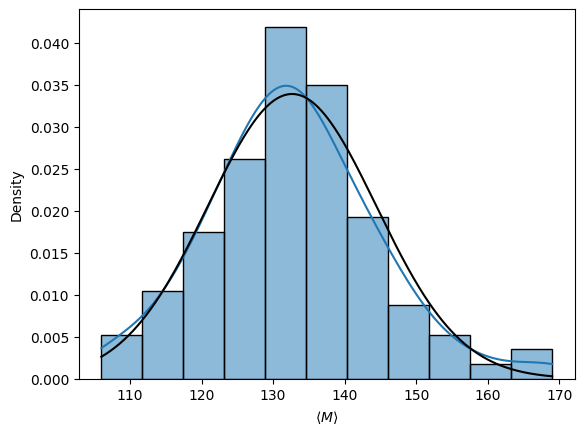

In [65]:
sns.histplot(M_f, stat='density', kde=True)
sns.lineplot(np.linspace(min(M_f), max(M_f), 300),
         1/(np.std(M_f)*np.sqrt(2*np.pi)) *
         np.exp(-(np.linspace(min(M_f), max(M_f), 300)-np.mean(M_f))**2 /
                (2*np.std(M_f)**2)), color='black')
plt.xlabel(r"${\langle}M{\rangle}$")

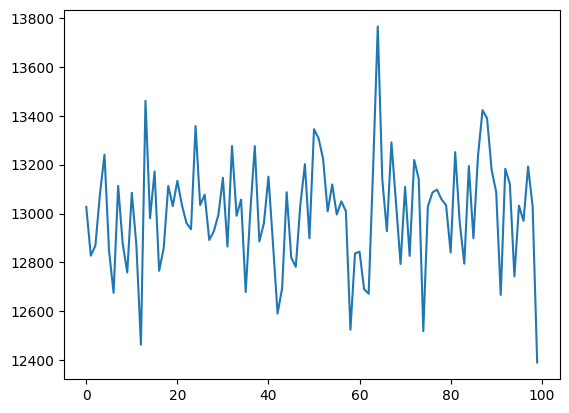

In [ ]:
plt.plot(P_f)


/Users/peterclark/opt/anaconda3/envs/main/lib/python3.10/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 0, '${\\langle}P{\\rangle}$')

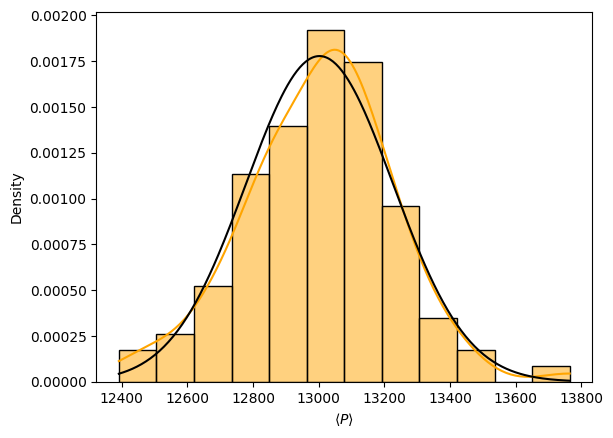

In [66]:
sns.histplot(P_f, stat='density', kde=True, color='orange')
sns.lineplot(np.linspace(min(P_f), max(P_f), 300),
         1/(np.std(P_f)*np.sqrt(2*np.pi)) *
         np.exp(-(np.linspace(min(P_f), max(P_f), 300)-np.mean(P_f))**2 /
                (2*np.std(P_f)**2)), color='black')
plt.xlabel(r"${\langle}P{\rangle}$")

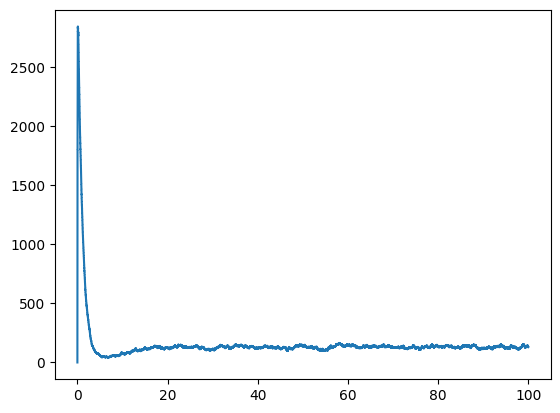

In [29]:
plt.plot(t, M)


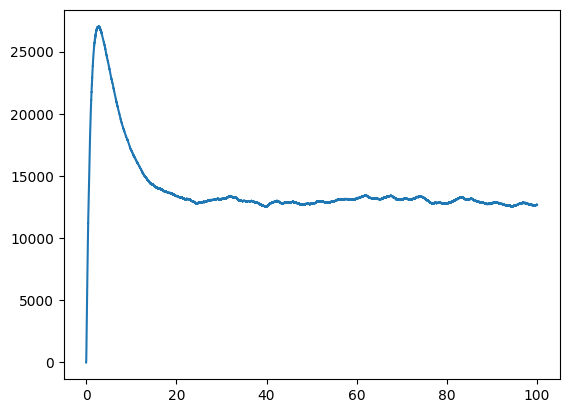

In [35]:
plt.plot(t, P)